# **Recreating a Pre-trained AlexNet on `numpy`**

Submitted by: Pangilinan, Reignel Bernice      2018-01460

## **Build the dataset and dataloader**

In [ ]:
# Mount Google drive and define the dataset path
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
dataset_path = '/content/drive/MyDrive/AI 231/data' # Change this as needed
# Note: Both ILSVRC2012_img_val and ILSVRC2012_devkit should be in the same folder
# for proper loading of images and labels.

Mounted at /content/drive


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

# Define the transformations, similar to the Pytorch implementation
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


val_dataset = torchvision.datasets.ImageNet(root = dataset_path, split = 'val', transform = transform)
text_labels = val_dataset.classes

# Use a large batch size and multiple workers for faster loading
batch_size = 1024
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)  # No shuffling, we should expect the same results
print(f"DataLoader created with batch size: {batch_size}")

DataLoader created with batch size: 1024


## **Visualize samples from the dataset**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get 16 random indices
indices = np.random.choice(len(val_dataset), size = 16, replace = False)

# Get the corresponding images and labels
images = [val_dataset[i][0] for i in indices]
labels_display = [text_labels[val_dataset[i][1]] for i in indices]

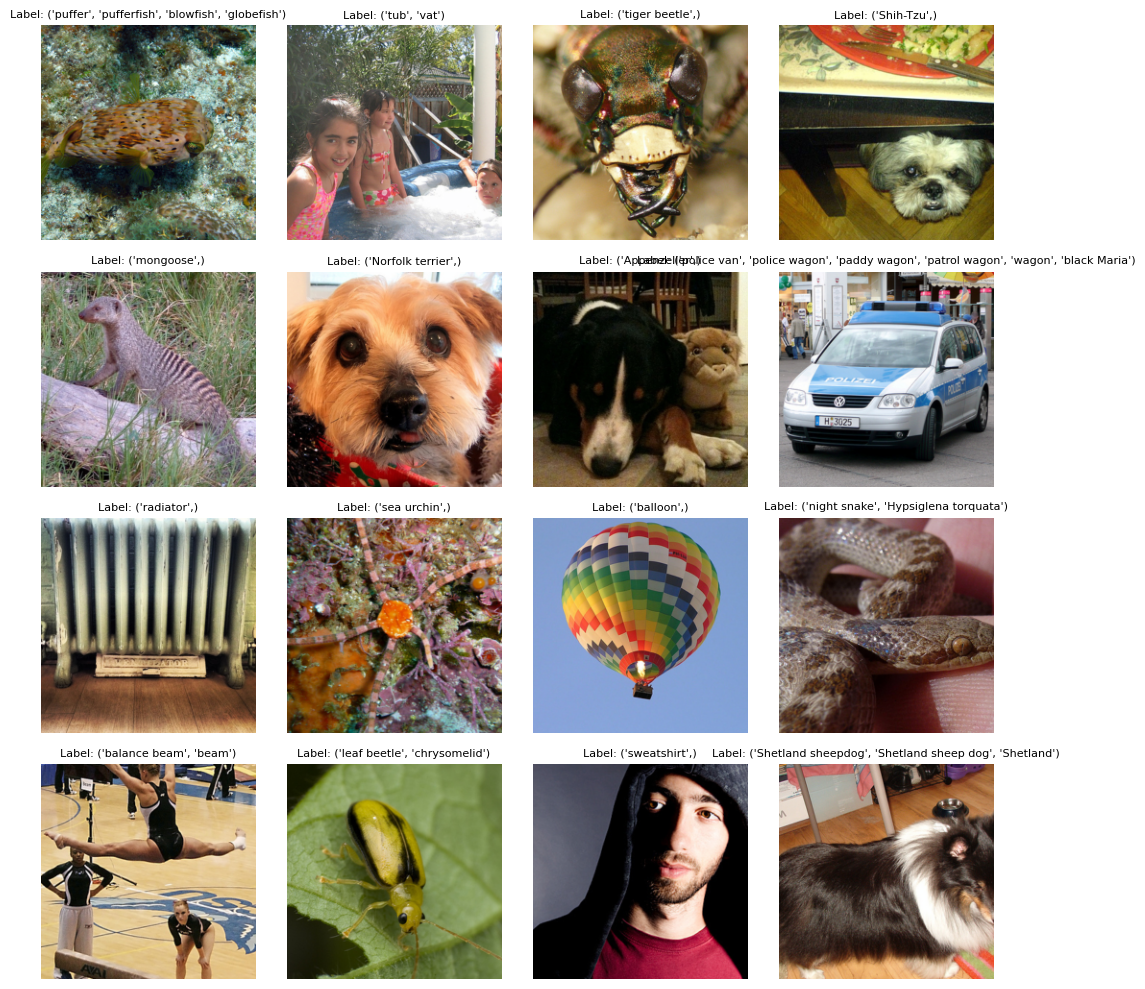

In [ ]:
# Create a figure with 4x4 subplots
fig, axes = plt.subplots(4, 4, figsize = (10, 10))

for i, ax in enumerate(axes.flat):
    # Get the image tensor (guaranteed to be a torch.Tensor as per user)
    img = images[i]

    # Transpose the image from (channel, height, width) to (height, width, channel)
    # and convert to a NumPy array for displaying with matplotlib
    img_np = img.numpy().transpose((1, 2, 0))

    # The images are normalized, un-normalize for display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1) # Clip to valid range [0, 1]


    ax.imshow(img_np)
    ax.set_title(f"Label: {labels_display[i]}", fontsize = 8)   # Display the label
    ax.axis('off')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the figure
plt.show()

## **Load the pre-trained weights**

In [ ]:
import torchvision
import numpy as np

# Load pretrained AlexNet
alexnet = torchvision.models.alexnet(weights = "IMAGENET1K_V1")
alexnet.eval()


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 149MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
# Convert weights and biases to numpy arrays and save in a dictionary
weights = {}
biases = {}

for name, param in alexnet.state_dict().items():
    if "weight" in name:
        weights[name] = param.cpu().numpy()
    elif "bias" in name:
        biases[name] = param.cpu().numpy()

## **AlexNet architecture in `numpy`**

In [ ]:
import numpy as np

def Conv2d(x, weight, bias, stride=1, padding=0):
  """
    Inputs:      x, batch of pre-processed images from the DataLoader
            weight, weights per layer of the CNN AlexNet model
              bias, bias per layer of the CNN AlexNet model
            stride, "number of jumps" of the kernel when "sliding through" the image
           padding, constant for padding the image

    Returns:   out, output of the convolution layer ((kernel (*) image patch) for all images in a batch)
  """
    N, C, H, W = x.shape        # batch_size, channel, height, width
    F, _, KH, KW = weight.shape     # filters, channel, kernel height, kernel width

    OH = (H + 2 * padding - KH) // stride + 1       # output height
    OW = (W + 2 * padding - KW) // stride + 1       # output width

    if padding > 0:
        x_padded = np.pad(x, ((0, 0), (0, 0), (padding, padding), (padding, padding)), mode='constant') # pad height and width using numpy with 0s
    else:
        x_padded = x

    # im2col for faster convolution
    i0 = np.repeat(np.arange(KH), KW)   # Repeating sequence for kernel height indices
    i0 = np.tile(i0, C)   # Repeat sequence of kernel heights C number of times (for each channel)
    i1 = stride * np.repeat(np.arange(OH), OW)    # Output height indices scaled by the stride

    j0 = np.tile(np.arange(KW), KH * C)   # Repeat sequence of kernel widths kernel height * C number of times (for each channel)
    j1 = stride * np.tile(np.arange(OW), OH)  # Output width indices scaled by the stride

    i = i0.reshape(-1, 1) + i1.reshape(1, -1)
    j = j0.reshape(-1, 1) + j1.reshape(1, -1)
    k = np.repeat(np.arange(C), KH * KW).reshape(-1, 1)   # Repeating sequence for each channel C

    cols = x_padded[:, k, i, j]  # (N, C*KH*KW, OH*OW), image patches (kernel (*) image patch)
    cols = cols.transpose(1, 2, 0).reshape(C * KH * KW, -1)  # (C*KH*KW, N*OH*OW), reshaped patches for matmul

    w_col = weight.reshape(F, -1)  # (F, C*KH*KW), reshaped weights for matmul
    out = w_col @ cols + bias.reshape(-1, 1)  # (F, N*OH*OW), perform matmul and add the bias

    out = out.reshape(F, OH, OW, N).transpose(3, 0, 1, 2)  # (N, F, OH, OW), reshaped back to original dims
    return out

def MaxPool2d(x, kernel_size=3, stride=2):      # Default values according to AlexNet
  """
    Inputs:     x, batch of pre-processed images from the DataLoader
      kernel_size, size of the square kernel
           stride, "number of jumps" of the kernel when "sliding through" the image

    Returns:  max value of image patch ((kernel (*) image patch) for all images in a batch) -> downsampling
  """
    N, C, H, W = x.shape        # batch_size, channel, height, width
    OH = (H - kernel_size) // stride + 1    # output height
    OW = (W - kernel_size) // stride + 1    # output width

    # im2col for faster max pooling
    # Logic of operation same as Conv2d
    i0 = np.repeat(np.arange(kernel_size), kernel_size)
    i1 = stride * np.repeat(np.arange(OH), OW)

    j0 = np.tile(np.arange(kernel_size), kernel_size)
    j1 = stride * np.tile(np.arange(OW), OH)

    i = i0.reshape(-1, 1) + i1.reshape(1, -1)
    j = j0.reshape(-1, 1) + j1.reshape(1, -1)

    x_reshaped = x[:, :, i, j]  # (N, C, k*k, OH*OW), image patches (kernel (*) image patch)
    x_reshaped = x_reshaped.reshape(N, C, kernel_size * kernel_size, OH, OW)  # Reshaped image patch
    return np.max(x_reshaped, axis=2)   # Get the max of the image patch (downsampling)

def Linear(x, weight, bias):
  """
    Inputs:     x, batch of pre-processed images from the DataLoader
           weight, weights per layer of the CNN AlexNet model
             bias, bias per layer of the CNN AlexNet model

    Returns:  output of the linear layer (for all images in a batch)
  """
    return x @ weight.T + bias # matmul of image and weight + bias

def ReLU(x):
  """
    Inputs:     x, batch of pre-processed images from the DataLoader

    Returns:  maximum according to the ReLU function (for all images in a batch)
  """
    return np.maximum(0, x)

def Dropout(x, p=0.5, training=True):   # Default value for p according to AlexNet. Included this for completeness though only evaluation is performed.
  """
    Inputs:     x, batch of pre-processed images from the DataLoader
                p, probability (Bernoulli) in dropping out
         training, boolean value (True or False)whether in training or evaluation mode

    Returns:   masked output of the dropout layer (for all images in a batch)
  """
    if not training or p == 0.0:
        return x
    mask = (np.random.rand(*x.shape) > p).astype(x.dtype) / (1.0 - p)   # Do 'masking' to perform dropout
    return x * mask

def AlexNetNumpy(x, weights, biases, training=True):
  """
    Inputs:     x, batch of pre-processed images from the DataLoader
           weight, weights per layer of the CNN AlexNet model
             bias, bias per layer of the CNN AlexNet model
         training, boolean value (True or False)whether in training or evaluation mode

    Returns:  one-hot encoded output of the CNN (for all images in a batch)
  """
    # Operations per layer is based on AlexNet architecture, model details in previous cells
    # Use weights and bias keys in the dictionary loaded from the pre-trained AlexNet
    x = Conv2d(x, weights['features.0.weight'], biases['features.0.bias'], stride=4, padding=2)
    x = ReLU(x)
    x = MaxPool2d(x, kernel_size=3, stride=2)

    x = Conv2d(x, weights['features.3.weight'], biases['features.3.bias'], stride=1, padding=2)
    x = ReLU(x)
    x = MaxPool2d(x, kernel_size=3, stride=2)

    x = Conv2d(x, weights['features.6.weight'], biases['features.6.bias'], stride=1, padding=1)
    x = ReLU(x)

    x = Conv2d(x, weights['features.8.weight'], biases['features.8.bias'], stride=1, padding=1)
    x = ReLU(x)

    x = Conv2d(x, weights['features.10.weight'], biases['features.10.bias'], stride=1, padding=1)
    x = ReLU(x)
    x = MaxPool2d(x, kernel_size=3, stride=2)

    # Flatten
    x = x.reshape(x.shape[0], -1)

    # Classification
    x = Dropout(x, p=0.5, training=training)
    x = Linear(x, weights['classifier.1.weight'], biases['classifier.1.bias'])
    x = ReLU(x)

    x = Dropout(x, p=0.5, training=training)
    x = Linear(x, weights['classifier.4.weight'], biases['classifier.4.bias'])
    x = ReLU(x)

    x = Linear(x, weights['classifier.6.weight'], biases['classifier.6.bias'])
    return x

## **Evaluate on validation set**

In [ ]:
from tqdm import tqdm
def evaluate(model, dataloader, weights, biases):
  """
    Inputs:     model, the Alexnet model recreated using Numpy
           dataloader, pre-built dataloader containing batch of images and their corresponding labels
               weight, weights per layer of the CNN AlexNet model
                 bias, bias per layer of the CNN AlexNet model

    Returns: top1_acc, accuracy on the top 1 prediction
             top5_acc, accuracy on the top 5 prediction
  """
    correct_top1 = 0
    correct_top5 = 0
    total = 0

    for inputs, labels in tqdm(dataloader, desc="Evaluating", unit="batch"):
        # Convert tensors to numpy to work with our AlexNetNumpy model
        inputs = inputs.numpy()
        labels = labels.numpy()

        # Forward pass
        outputs = model(inputs, weights, biases, training=False)  # (N, 1000)

        # Top-1 prediction
        preds_top1 = np.argmax(outputs, axis=1)   # argmax to retrieve the ID of the top 1 predicted label
        correct_top1 += np.sum(preds_top1 == labels)    # Collect all top 1 predictions in a single batch

        # Top-5 prediction
        preds_top5 = np.argsort(outputs, axis=1)[:, -5:]  # last 5 are top-5
        correct_top5 += np.sum([label in preds for label, preds in zip(labels, preds_top5)])    # Collect the top 5 predictions in a single batch

        total += labels.shape[0]

    top1_acc = correct_top1 / total
    top5_acc = correct_top5 / total
    return top1_acc, top5_acc


In [ ]:
top_1acc, top_5acc = evaluate(AlexNetNumpy, val_dataloader, weights, biases)

Evaluating: 100%|██████████| 49/49 [1:49:04<00:00, 133.57s/batch]


In [ ]:
print(f"acc@1: {top_1acc*100:.3f} \t acc@5: {top_5acc*100:.3f}")

acc@1: 56.556 	 acc@5: 79.084


These results agree with those of the `pytorch` equivalent of the AlexNet model.

In [ ]:
# Make predictions on the sample images in the previous sections

sample = indices
images_list = [val_dataset[i][0] for i in sample]
true_labels = [text_labels[val_dataset[i][1]] for i in sample]

# Convert list of tensors to a single numpy array (for making predictions using AlexNetNumpy)
images = np.stack([img.numpy() for img in images_list])
predicted = np.argmax(AlexNetNumpy(images, weights, biases, training=False), axis=1)
predicted_labels = [text_labels[i] for i in predicted]

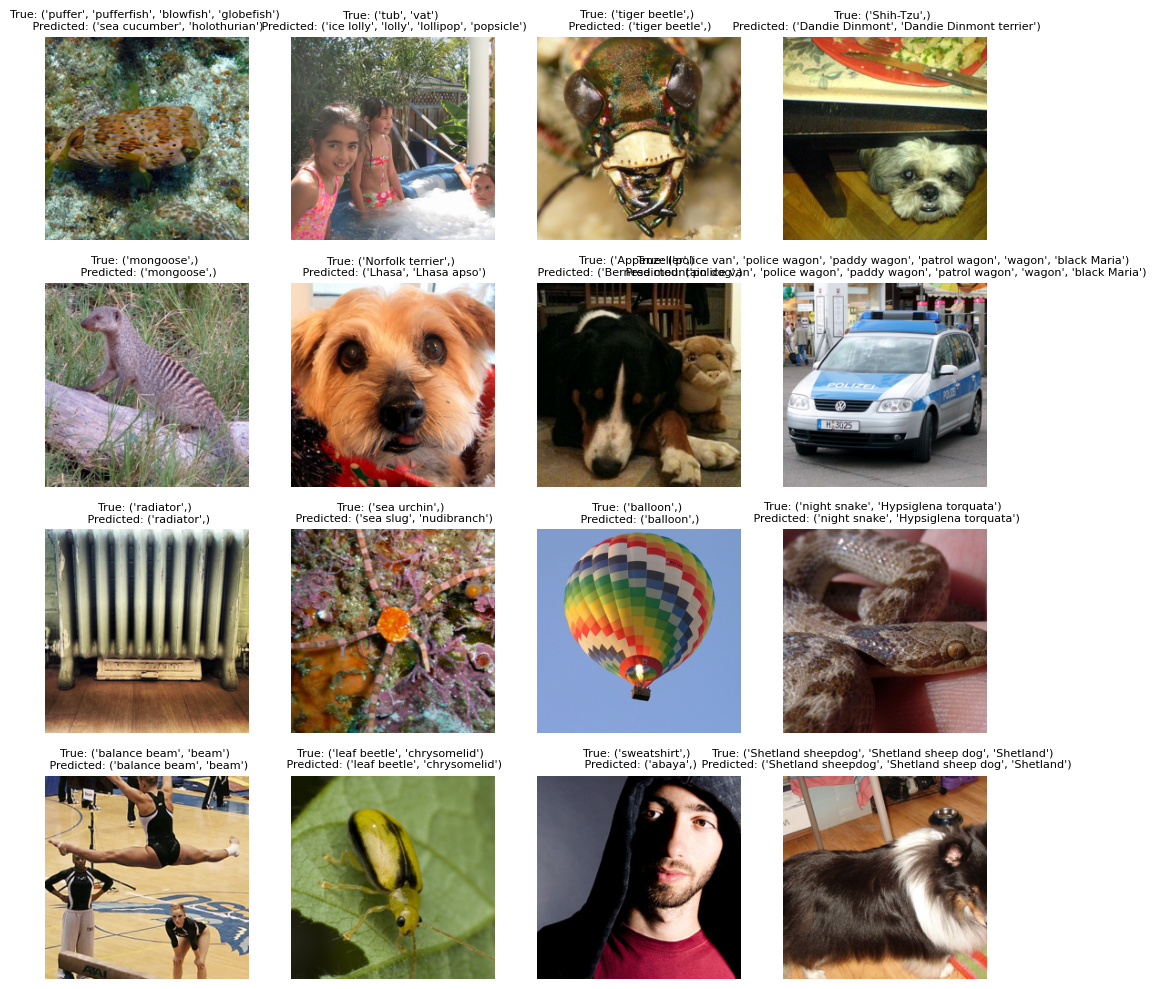

In [ ]:
fig, axes = plt.subplots(4, 4, figsize = (10, 10))

for i, ax in enumerate(axes.flat):
    # Get the image tensor (guaranteed to be a torch.Tensor as per user)
    img = images_list[i]

    # Transpose the image from (channel, height, width) to (height, width, channel)
    # and convert to a NumPy array for displaying with matplotlib
    img_np = img.numpy().transpose((1, 2, 0))

    # The images are normalized, un-normalize for display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1) # Clip to valid range [0, 1]


    ax.imshow(img_np)
    ax.set_title(f"True: {true_labels[i]} \n Predicted: {predicted_labels[i]}", fontsize = 8)   # Display the true and predicted labels
    ax.axis('off')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the figure
plt.show()

The results here show that indeed, the AlexNet model recreated using `numpy` is able to predict correctly around ~56% of the time. Out of the 16 images displayed in the sample, 9 were predicted correctly while the other 7 were mislabelled.